In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim

The dataset I have used in this example is the WI Breast Cancer diagnostic data. More info is available here: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic. It is actually built-in to sk-learn so I've used that library to load the data below.

In [2]:
# Loading the data and some preprocessing:
wdbc = load_breast_cancer(as_frame=True)
X, y = wdbc.data, wdbc.target

# Scale data (crucial for neural networks)
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X).astype(np.float32))
y = pd.DataFrame(y.astype(np.float32))

# train / test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=499)

# train / val split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=499)

display(X_train.head())
display(y_train.head())

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
6,1.170908,0.160649,1.138125,1.095295,-0.123136,0.088295,0.300072,0.646935,-0.064325,-0.762332,...,1.368983,0.322883,1.368325,1.275220,0.518640,0.021215,0.509552,1.196716,0.262476,-0.014730
404,-0.507616,-1.009865,-0.563442,-0.528403,-0.678938,-1.111144,-0.850088,-0.732011,-0.878485,-0.810531,...,-0.639717,-1.437459,-0.689578,-0.610845,-1.208494,-1.188468,-1.069744,-1.015252,-0.975127,-1.341385
519,-0.391170,-0.602629,-0.389619,-0.458154,1.148590,0.139464,-0.627740,-0.489290,1.125883,0.486577,...,-0.376722,-0.641152,-0.406017,-0.450875,0.663299,-0.358560,-0.623143,-0.520083,0.275418,0.090005
267,-0.152598,0.593484,-0.198085,-0.267030,-1.195599,-0.412213,-0.603634,-0.709312,-0.644825,-0.596473,...,-0.304244,0.710451,-0.285980,-0.385129,-1.396988,-0.516959,-0.608750,-0.802689,-0.735695,-0.759519
342,-0.871154,-1.007538,-0.843535,-0.799162,0.493868,-0.253400,-0.437281,-0.400043,-0.130042,0.889177,...,-0.900641,-0.940785,-0.819147,-0.774507,0.413434,-0.211612,-0.202880,-0.108204,0.647507,0.379830


,target
6,0.0
404,1.0
519,1.0
267,1.0
342,1.0


The following code block defines 2 model classes: one with dropout and one without.

In [3]:
class FCNN(nn.Module):
  def __init__(self, input_size):
    super(FCNN, self).__init__()
    self.fc1 = nn.Linear(input_size, 32)
    self.fc2 = nn.Linear(32, 32)
    self.fc3 = nn.Linear(32, 1)
    self.sigmoid = nn.Sigmoid()
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.relu(x)
    x = self.fc3(x)
    return self.sigmoid(x)

class FCNNreg(nn.Module):
  def __init__(self, input_size):
    super(FCNNreg, self).__init__()
    self.fc1 = nn.Linear(input_size, 32)
    self.fc2 = nn.Linear(32, 32)
    self.fc3 = nn.Linear(32, 1)
    self.dropout = nn.Dropout(0.2)
    self.sigmoid = nn.Sigmoid()
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.fc2(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.fc3(x)
    return self.sigmoid(x)

In [4]:
# To use PyTorch you must convert our data to PyTorch tensors
X_train_torch = torch.tensor(X_train.values, dtype=torch.float32)
y_train_torch = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_val_torch = torch.tensor(X_val.values, dtype=torch.float32)
y_val_torch = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

# Initialize the models we defined above
model = FCNN(input_size=X_train.shape[1])
model_drop = FCNNreg(input_size=X_train.shape[1])
model_weight_decay = FCNN(input_size=X_train.shape[1])

# Define our Loss function and algorithm for optimization (aka our 'Optimizer')
criterion = nn.BCELoss()
model_optimizer = optim.SGD(model.parameters(), lr=0.005)
model_drop_optimizer = optim.SGD(model_drop.parameters(), lr=0.005)
model_weight_decay_optimizer = optim.SGD(model_weight_decay.parameters(), lr=0.01, weight_decay=0.005)

# Dictionaries for Loss Values
train_losses = {'model': [], 'dropout': [], 'weight_decay': []}
val_losses = {'model': [], 'dropout': [], 'weight_decay': []}

# training loop
epochs = 50_000

for epoch in range(epochs):

    model.train()
    model_drop.train()
    model_weight_decay.train()

    # forward pass
    model_y_pred = model(X_train_torch)
    model_drop_y_pred = model_drop(X_train_torch)
    model_weight_decay_y_pred = model_weight_decay(X_train_torch)

    # calculate the cost not the loss but all PyTorch syntax calls this the loss
    model_loss = criterion(model_y_pred, y_train_torch)
    model_drop_loss = criterion(model_drop_y_pred, y_train_torch)
    model_weight_decay_loss = criterion(model_weight_decay_y_pred, y_train_torch)
    train_losses['model'].append(model_loss.item())
    train_losses['dropout'].append(model_drop_loss.item())
    train_losses['weight_decay'].append(model_weight_decay_loss.item())

    # backprop
    model_optimizer.zero_grad()
    model_drop_optimizer.zero_grad()
    model_weight_decay_optimizer.zero_grad()
    model_loss.backward()
    model_drop_loss.backward()
    model_weight_decay_loss.backward()
    model_optimizer.step()
    model_drop_optimizer.step()
    model_weight_decay_optimizer.step()

    # validation predictions and loss
    model.eval()
    model_drop.eval()
    model_weight_decay.eval()
    with torch.no_grad():
        model_y_val_pred = model(X_val_torch)
        model_drop_y_val_pred = model_drop(X_val_torch)
        model_weight_decay_y_val_pred = model_weight_decay(X_val_torch)
        val_losses['model'].append(criterion(model_y_val_pred, y_val_torch))
        val_losses['dropout'].append(criterion(model_drop_y_val_pred, y_val_torch))
        val_losses['weight_decay'].append(criterion(model_weight_decay_y_val_pred, y_val_torch))

    # print out metrics during training
    with torch.no_grad():
        if epoch % 2000 == 0:
            print()
            print(f'Epoch: {epoch}')
            print(f'Train Losses:')
            print(f'Model {model_loss.item()}, Dropout {model_drop_loss.item()}, Weight Decay {model_weight_decay_loss.item()}')
            print(f'Validation Losses:')
            print(f'Model {val_losses["model"][-1]}, Dropout {val_losses["dropout"][-1]}, Weight Decay {val_losses["weight_decay"][-1]}')

print()
print('Training Complete.')
print()


/Users/itzjuztmya/miniconda3/envs/school/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Epoch: 0
Train Losses:
Model 0.7251785397529602, Dropout 0.7192175984382629, Weight Decay 0.6685949563980103
Validation Losses:
Model 0.7176029682159424, Dropout 0.7201202511787415, Weight Decay 0.6611328721046448

Epoch: 2000
Train Losses:
Model 0.08247207850217819, Dropout 0.0908602625131607, Weight Decay 0.041184086352586746
Validation Losses:
Model 0.15898148715496063, Dropout 0.17030209302902222, Weight Decay 0.17658686637878418

Epoch: 4000
Train Losses:
Model 0.04525982216000557, Dropout 0.04966495931148529, Weight Decay 0.028802158311009407
Validation Losses:
Model 0.17358975112438202, Dropout 0.19255483150482178, Weight Decay 0.193182110786438

Epoch: 6000
Train Losses:
Model 0.03245682641863823, Dropout 0.031639739871025085, Weight Decay 0.023322777822613716
Validation Losses:
Model 0.1942061185836792, Dropout 0.21428319811820984, Weight Decay 0.20264315605163574

Epoch: 8000
Train Losses:
Model 0.025516243651509285, Dropout 0.026571188122034073, Weight Decay 0.0202020332217

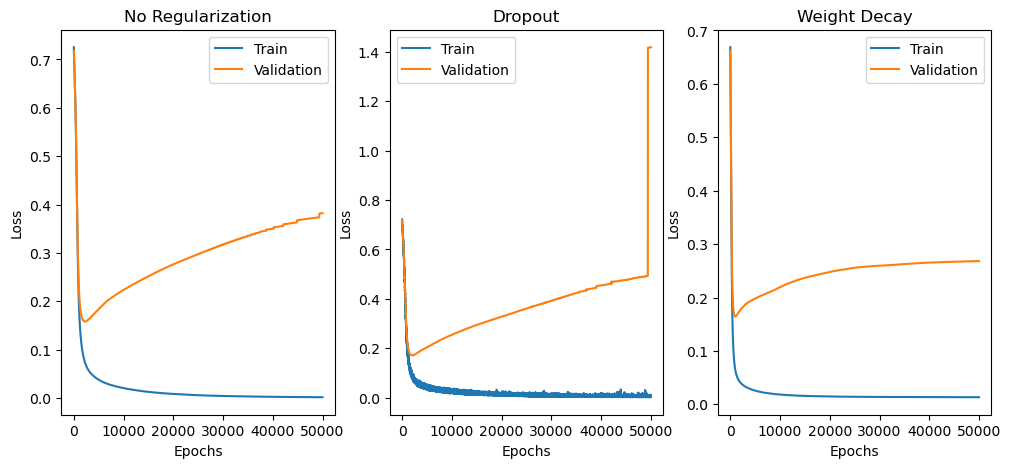

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses['model'], label='Train')
plt.plot(val_losses['model'], label='Validation')
plt.title('No Regularization')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(train_losses['dropout'], label='Train')
plt.plot(val_losses['dropout'], label='Validation')
plt.title('Dropout')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(train_losses['weight_decay'], label='Train')
plt.plot(val_losses['weight_decay'], label='Validation')
plt.title('Weight Decay')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()